In [1]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [3]:
!pip install seaborn


Defaulting to user installation because normal site-packages is not writeable


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

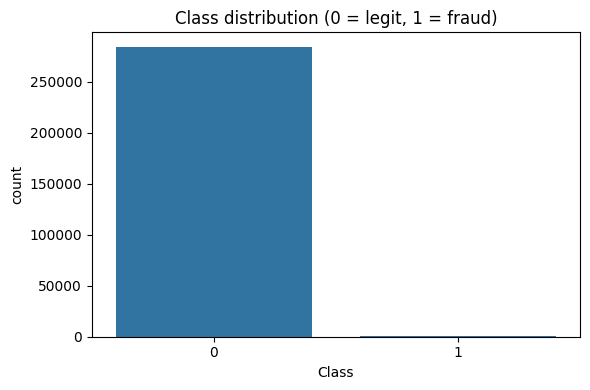

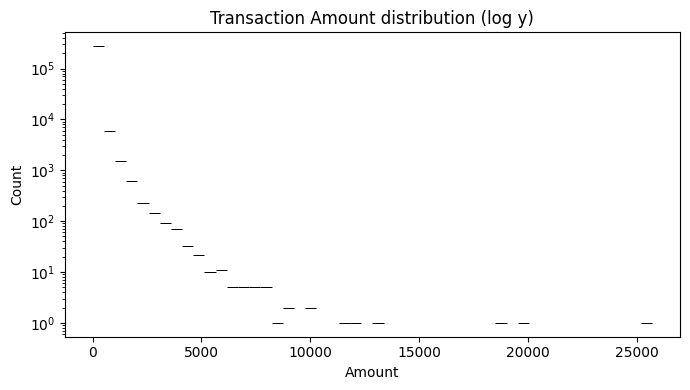

In [4]:
# Load the dataset and do a quick sanity check (head + class balance)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

credit_df = pd.read_csv('creditcard.csv')
print(credit_df.head())
print(credit_df[['Amount','Class']].describe())
print(credit_df['Class'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=credit_df, x='Class')
plt.title('Class distribution (0 = legit, 1 = fraud)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
sns.histplot(data=credit_df, x='Amount', bins=50, log_scale=(False, True))
plt.title('Transaction Amount distribution (log y)')
plt.tight_layout()
plt.show()

C:\Users\Acer\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                                  ROC_AUC    PR_AUC  Precision    Recall  \
Existing baseline (LogReg @0.5)  0.973544  0.720430   0.058785  0.918367   
Proposed stack (dynamic thr)     0.974189  0.714824   0.811881  0.836735   

                                       F1     Brier  
Existing baseline (LogReg @0.5)  0.110497  0.023723  
Proposed stack (dynamic thr)     0.824121  0.025256  
Best threshold (stack, max F1 on PR):
0.9999834198302335


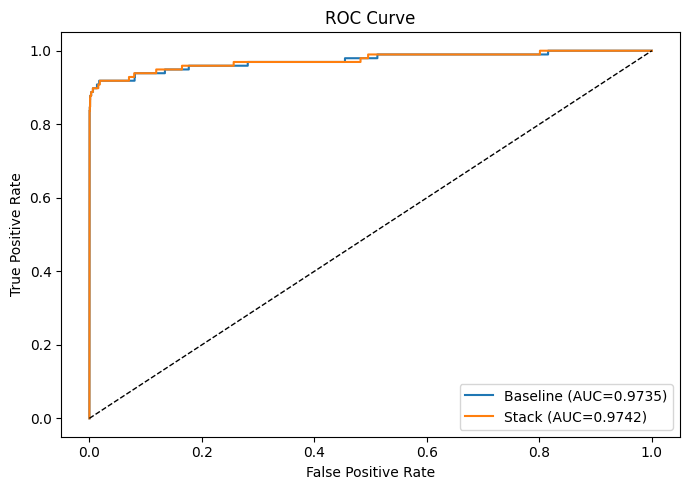

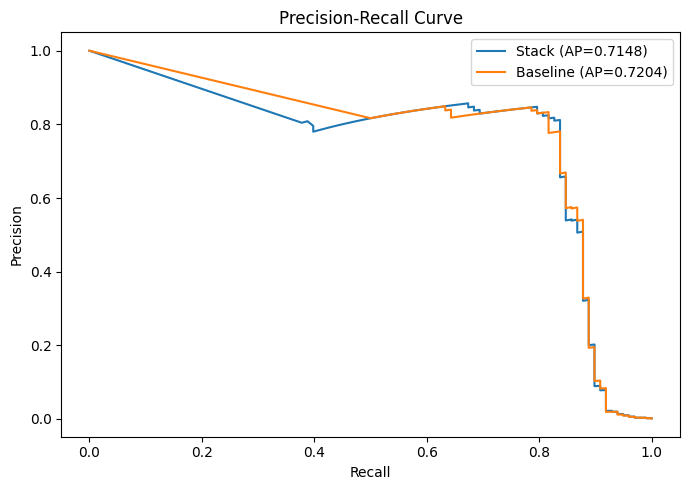

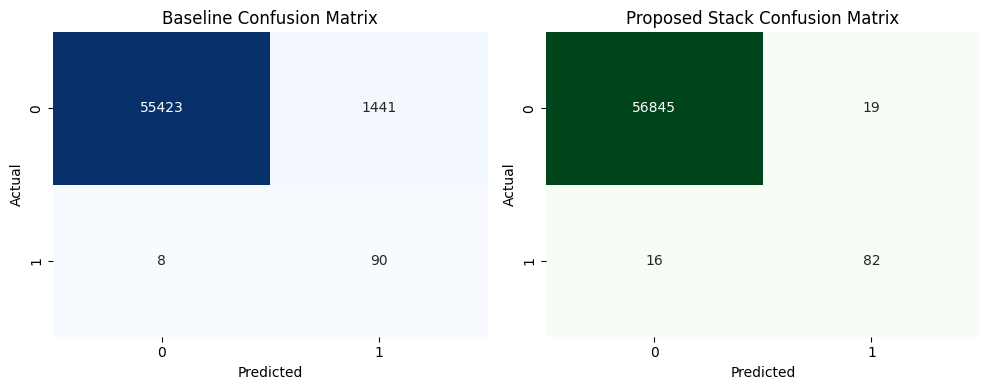

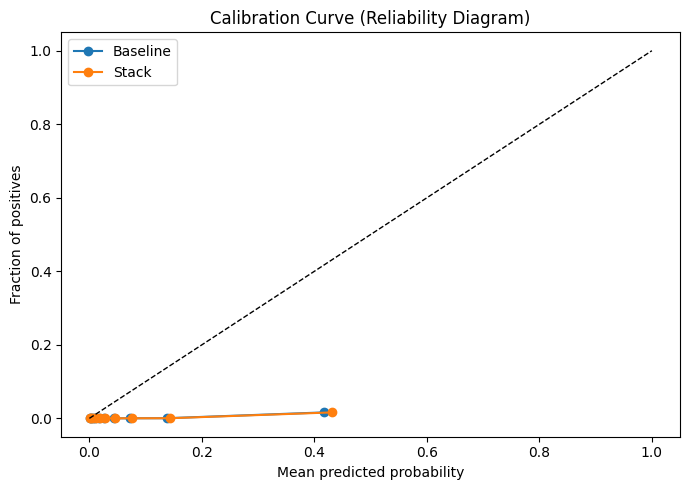

Baseline classification report (thr=0.5)
              precision    recall  f1-score   support

           0     0.9999    0.9747    0.9871     56864
           1     0.0588    0.9184    0.1105        98

    accuracy                         0.9746     56962
   macro avg     0.5293    0.9465    0.5488     56962
weighted avg     0.9982    0.9746    0.9856     56962

Stack classification report (thr=1.0)
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8119    0.8367    0.8241        98

    accuracy                         0.9994     56962
   macro avg     0.9058    0.9182    0.9119     56962
weighted avg     0.9994    0.9994    0.9994     56962



In [5]:
# Train baseline + proposed hybrid stacking, and produce core evaluation metrics + key visualizations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve,
    confusion_matrix, classification_report, f1_score, precision_score, recall_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.ensemble import StackingClassifier

# Optional gradient boosting libs
has_xgb = True
has_lgbm = True
has_cat = True
try:
    from xgboost import XGBClassifier
except Exception:
    has_xgb = False
try:
    from lightgbm import LGBMClassifier
except Exception:
    has_lgbm = False
try:
    from catboost import CatBoostClassifier
except Exception:
    has_cat = False

# Feature engineering: cyclical time + amount log
credit_df_fe = credit_df.copy()
credit_df_fe['Time_sin'] = np.sin(2 * np.pi * (credit_df_fe['Time'] % 86400) / 86400)
credit_df_fe['Time_cos'] = np.cos(2 * np.pi * (credit_df_fe['Time'] % 86400) / 86400)
credit_df_fe['Amount_log1p'] = np.log1p(credit_df_fe['Amount'])

feature_cols = [c for c in credit_df_fe.columns if c != 'Class']
X_all = credit_df_fe[feature_cols]
y_all = credit_df_fe['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# Baseline: Logistic Regression (typical existing solution)
baseline_model = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('lr', LogisticRegression(max_iter=2000, class_weight='balanced', n_jobs=None))
])

baseline_model.fit(X_train, y_train)
base_proba = baseline_model.predict_proba(X_test)[:, 1]

# Proposed: Stacking (LGBM, XGB, CatBoost) + Logistic meta-model
base_estimators = []
if has_lgbm:
    base_estimators.append(('lgbm', LGBMClassifier(
        n_estimators=600, learning_rate=0.05, num_leaves=64,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        class_weight='balanced'
    )))
if has_xgb:
    # scale_pos_weight based on training split
    scale_pos_weight_val = (y_train.value_counts()[0] / max(1, y_train.value_counts()[1]))
    base_estimators.append(('xgb', XGBClassifier(
        n_estimators=700, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, random_state=42,
        objective='binary:logistic', eval_metric='aucpr',
        scale_pos_weight=scale_pos_weight_val
    )))
if has_cat:
    base_estimators.append(('cat', CatBoostClassifier(
        iterations=800, learning_rate=0.05, depth=6,
        loss_function='Logloss', eval_metric='AUC',
        verbose=False, random_state=42,
        auto_class_weights='Balanced'
    )))

# Fallback if none installed
if len(base_estimators) == 0:
    from sklearn.ensemble import HistGradientBoostingClassifier
    base_estimators = [('hgb', HistGradientBoostingClassifier(max_depth=6, random_state=42))]

stack_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=2000, class_weight='balanced'),
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=True,
    cv=3
)

stack_model.fit(X_train, y_train)
stack_proba = stack_model.predict_proba(X_test)[:, 1]

# Dynamic thresholding: maximize F1 on PR curve (common practical choice)
prec_vals, rec_vals, thr_vals = precision_recall_curve(y_test, stack_proba)
# precision_recall_curve returns thresholds of length n-1
f1_vals = 2 * prec_vals[:-1] * rec_vals[:-1] / np.maximum(1e-12, (prec_vals[:-1] + rec_vals[:-1]))
best_idx = int(np.argmax(f1_vals))
best_thr = float(thr_vals[best_idx])

stack_pred = (stack_proba >= best_thr).astype(int)
base_pred = (base_proba >= 0.5).astype(int)

def metric_pack(y_true, proba, pred):
    return {
        'ROC_AUC': roc_auc_score(y_true, proba),
        'PR_AUC': average_precision_score(y_true, proba),
        'Precision': precision_score(y_true, pred, zero_division=0),
        'Recall': recall_score(y_true, pred, zero_division=0),
        'F1': f1_score(y_true, pred, zero_division=0),
        'Brier': brier_score_loss(y_true, proba)
    }

base_metrics = metric_pack(y_test, base_proba, base_pred)
stack_metrics = metric_pack(y_test, stack_proba, stack_pred)

metrics_df = pd.DataFrame([base_metrics, stack_metrics], index=['Existing baseline (LogReg @0.5)', 'Proposed stack (dynamic thr)'])
print(metrics_df)
print('Best threshold (stack, max F1 on PR):')
print(best_thr)

# Visualizations: ROC, PR, confusion matrices, calibration curve
fpr_b, tpr_b, _ = roc_curve(y_test, base_proba)
fpr_s, tpr_s, _ = roc_curve(y_test, stack_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr_b, tpr_b, label='Baseline (AUC=' + str(round(base_metrics['ROC_AUC'], 4)) + ')')
plt.plot(fpr_s, tpr_s, label='Stack (AUC=' + str(round(stack_metrics['ROC_AUC'], 4)) + ')')
plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(rec_vals, prec_vals, label='Stack (AP=' + str(round(stack_metrics['PR_AUC'], 4)) + ')')
prec_b, rec_b, _ = precision_recall_curve(y_test, base_proba)
plt.plot(rec_b, prec_b, label='Baseline (AP=' + str(round(base_metrics['PR_AUC'], 4)) + ')')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()

cm_base = confusion_matrix(y_test, base_pred)
cm_stack = confusion_matrix(y_test, stack_pred)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Baseline Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.subplot(1,2,2)
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Proposed Stack Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

frac_pos_b, mean_pred_b = calibration_curve(y_test, base_proba, n_bins=10, strategy='quantile')
frac_pos_s, mean_pred_s = calibration_curve(y_test, stack_proba, n_bins=10, strategy='quantile')

plt.figure(figsize=(7,5))
plt.plot(mean_pred_b, frac_pos_b, marker='o', label='Baseline')
plt.plot(mean_pred_s, frac_pos_s, marker='o', label='Stack')
plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve (Reliability Diagram)')
plt.legend()
plt.tight_layout()
plt.show()

# Show brief classification reports for both
print('Baseline classification report (thr=0.5)')
print(classification_report(y_test, base_pred, digits=4))
print('Stack classification report (thr=' + str(round(best_thr, 4)) + ')')
print(classification_report(y_test, stack_pred, digits=4))